# Name: Hissah Alkharboush

# Application:
Traffic

# Goal: 


# ML Task:


# Description:


# 1. Import Traffic Dataset

In [1]:
#Import Traffic Dataset
from pycaret.datasets import get_data

traffic_data = get_data('traffic')


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,Rush Hour,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,1,5545
1,NaN,289.36,0.0,0.0,75,Clouds,0,4516
2,NaN,289.58,0.0,0.0,90,Clouds,0,4767
3,NaN,290.13,0.0,0.0,90,Clouds,0,5026
4,NaN,291.14,0.0,0.0,75,Clouds,0,4918


# 2. Clean Data

- Handle holiday column by Convert missing values (NaN) to 'None' to represent a normal working day.
- Convert temperature from Kelvin to Celsius, Formula: Celsius = Kelvin - 273.15

In [2]:
import pandas as pd

# Handle missing values in 'holiday' and convert to Binary (0 and 1)
# We use 'None' to identify normal workdays, then map them to 0 and 1
traffic_data['holiday'] = traffic_data['holiday'].fillna('None')
traffic_data['is_holiday'] = traffic_data['holiday'].apply(lambda x: 0 if x == 'None' else 1)

# Convert temperature from Kelvin to Celsius
# Formula: Celsius = Kelvin - 273.15
traffic_data['temp'] = traffic_data['temp'] - 273.15

# Data Cleaning: Drop unnecessary columns
# We drop 'holiday' because we created 'is_holiday'
# We drop 'weather_description' to avoid overfitting (too many categories)
cols_to_drop = ['holiday']
traffic_data = traffic_data.drop(columns=cols_to_drop)

# Verify the final structure
print("Final columns in the dataset:")
print(traffic_data.columns)
print("\nFirst 5 rows of the cleaned data:")
traffic_data.head()

Final columns in the dataset:
Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'Rush Hour',
       'traffic_volume', 'is_holiday'],
      dtype='object')

First 5 rows of the cleaned data:


,temp,rain_1h,snow_1h,clouds_all,weather_main,Rush Hour,traffic_volume,is_holiday
0,15.13,0.0,0.0,40,Clouds,1,5545,0
1,16.21,0.0,0.0,75,Clouds,0,4516,0
2,16.43,0.0,0.0,90,Clouds,0,4767,0
3,16.98,0.0,0.0,90,Clouds,0,5026,0
4,17.99,0.0,0.0,75,Clouds,0,4918,0


X :
temp, rain_1h, snow_1h, clouds_all, weather_main, Rush Hour, is_holiday

Y :
traffic_volume

# 3. EDA

In [5]:
traffic_data.describe()

,temp,rain_1h,snow_1h,clouds_all,Rush Hour,traffic_volume,is_holiday
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,8.055870,0.334264,0.000222,49.362231,0.250124,3259.818355,0.001265
std,13.338232,44.789133,0.008168,39.015750,0.433089,1986.860670,0.035551
min,-273.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.990000,0.000000,0.000000,1.000000,0.000000,1193.000000,0.000000
50%,9.300000,0.000000,0.000000,64.000000,0.000000,3380.000000,0.000000
75%,18.656000,0.000000,0.000000,90.000000,1.000000,4933.000000,0.000000
max,36.920000,9831.300000,0.510000,100.000000,1.000000,7280.000000,1.000000


In [6]:
x = traffic_data[["temp", "rain_1h", "snow_1h", "clouds_all", "weather_main", "Rush Hour", "is_holiday"]]
y = traffic_data["traffic_volume"]

In [7]:
x.dtypes

temp            float64
rain_1h         float64
snow_1h         float64
clouds_all        int64
weather_main     object
Rush Hour         int64
is_holiday        int64
dtype: object

In [8]:
y.dtype

dtype('int64')

The target is numerical then the task is regression

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


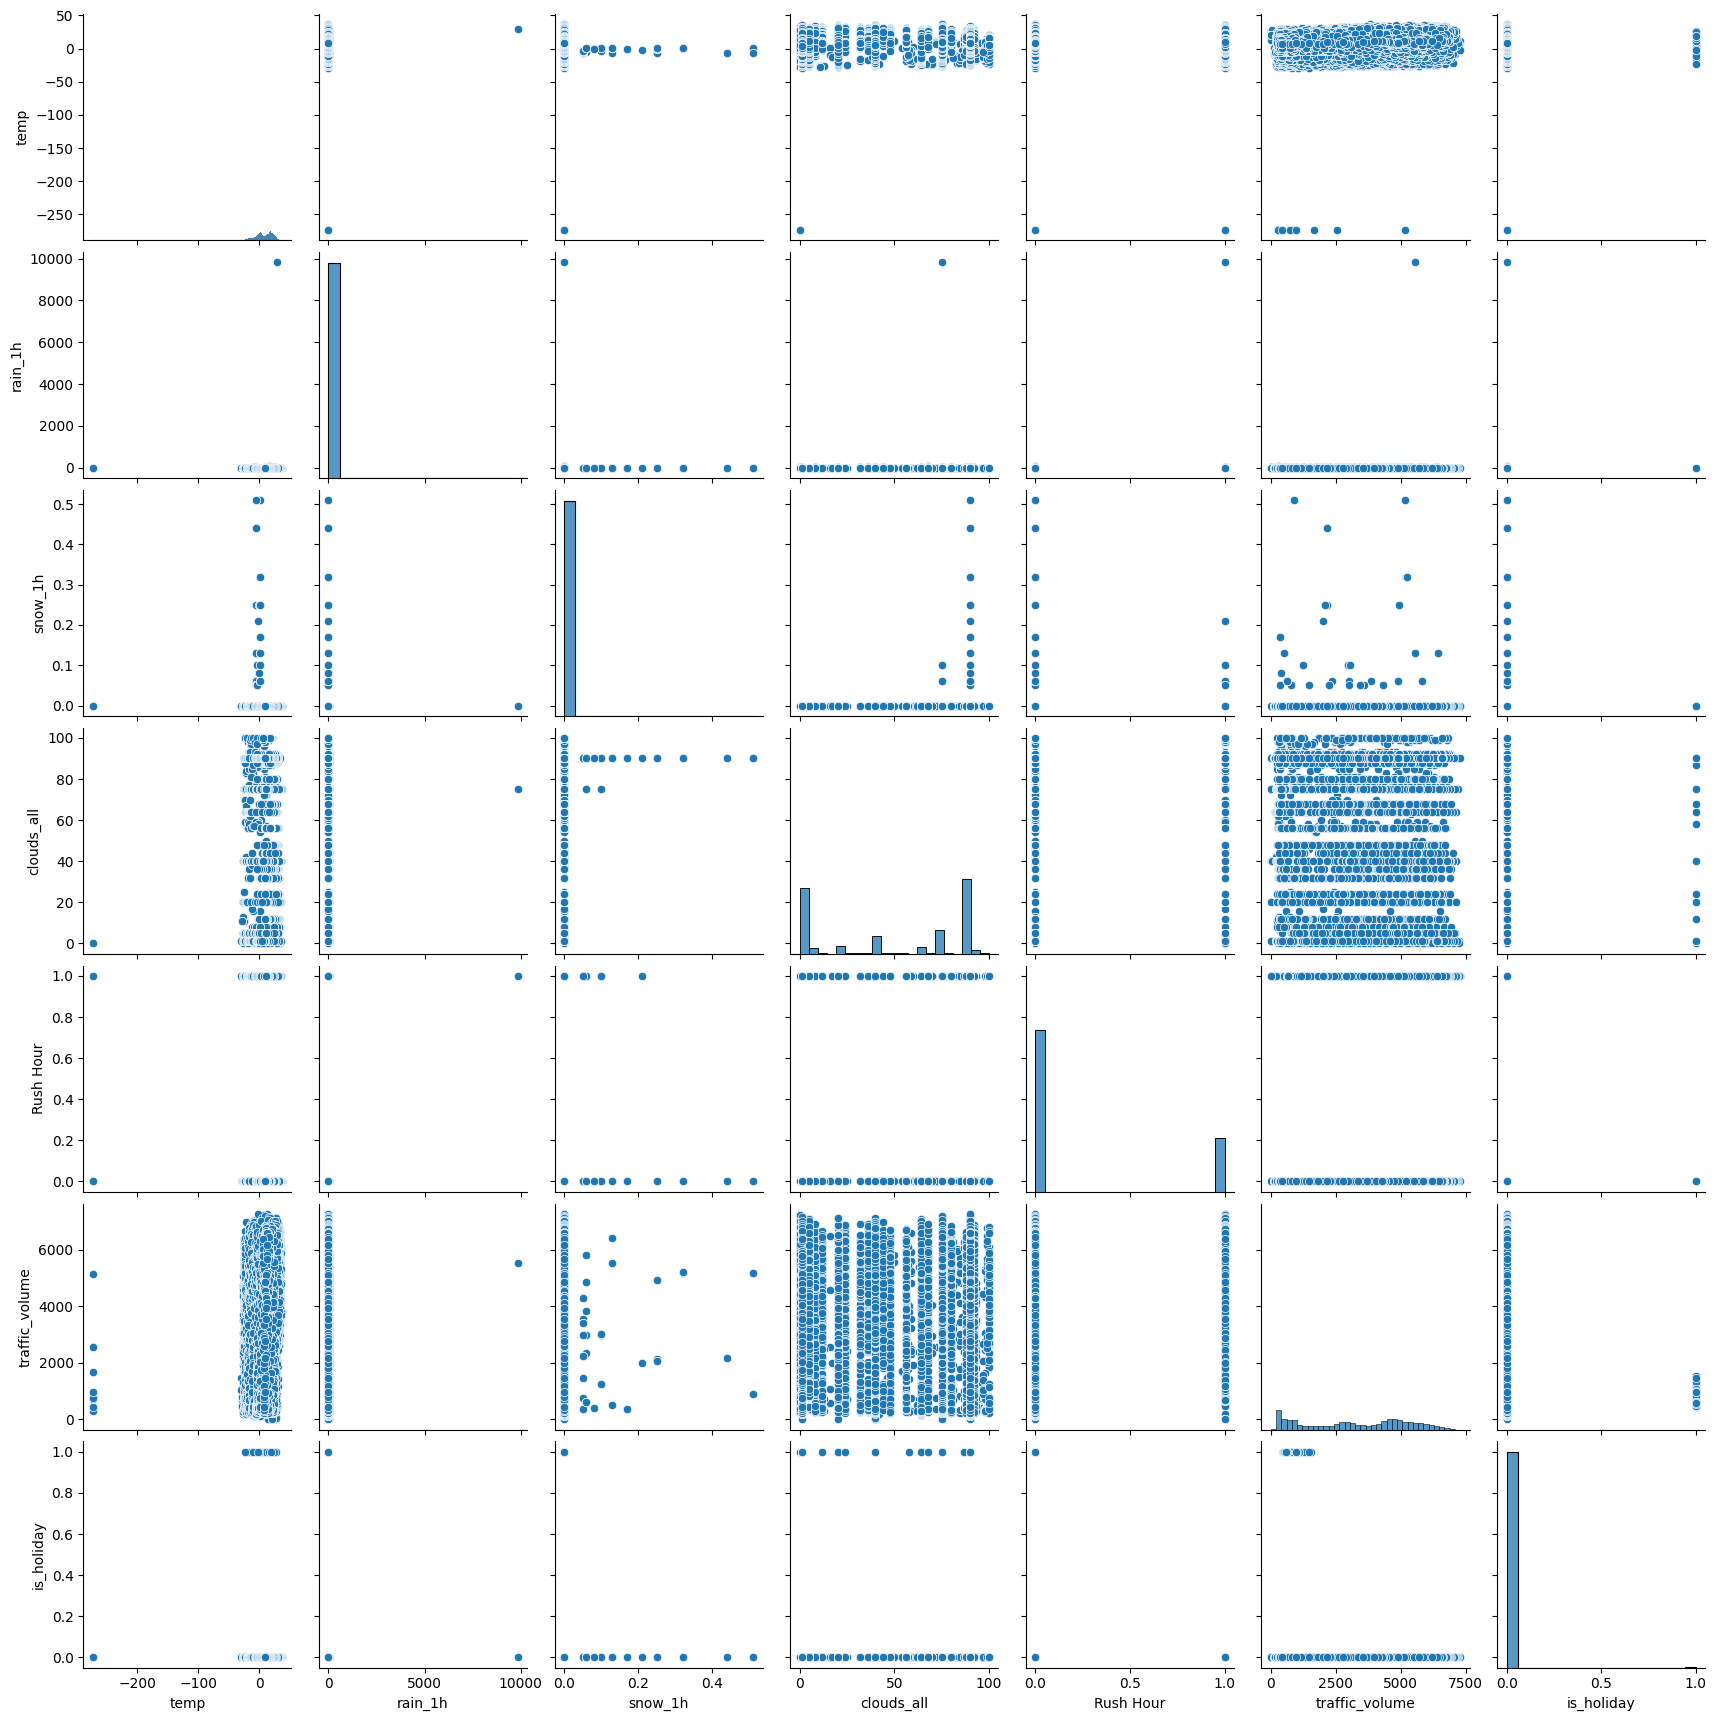

In [4]:
sns.pairplot(traffic_data)

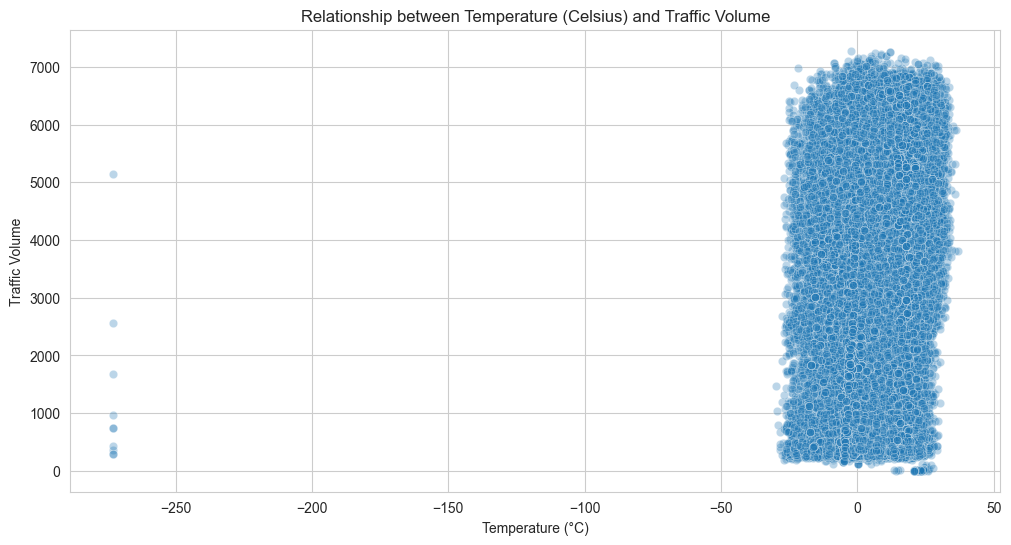

In [13]:

# Set plotting configurations for better visibility
plt.rcParams['figure.figsize'] = [12, 6]
sns.set_style("whitegrid")

# 1. Relationship between Temperature and Traffic Volume
# Using a Scatter Plot with 'alpha' to visualize point density and trends
plt.figure()
sns.scatterplot(data=traffic_data, x='temp', y='traffic_volume', alpha=0.3)
plt.title('Relationship between Temperature (Celsius) and Traffic Volume')
plt.xlabel('Temperature (°C)')
plt.ylabel('Traffic Volume')
plt.show()


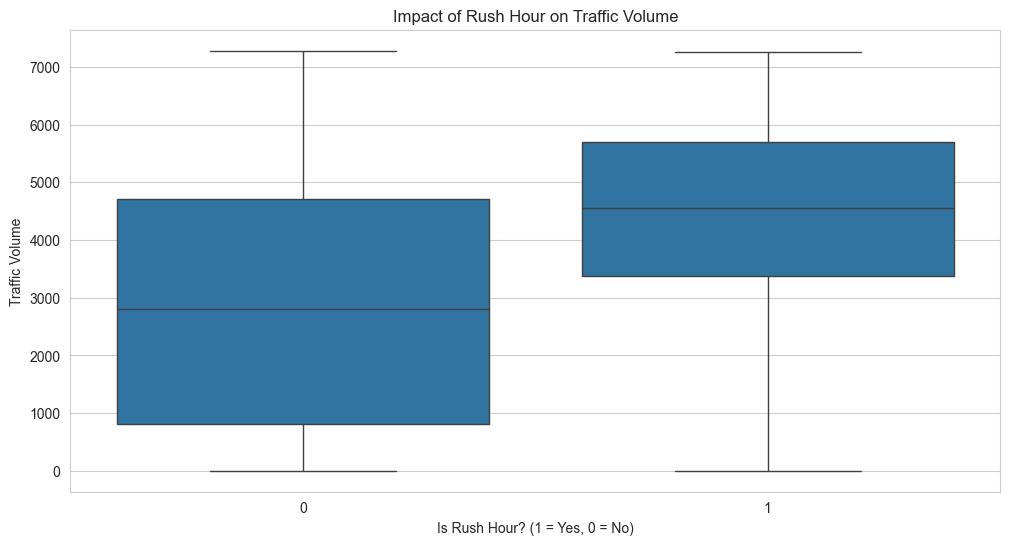

In [11]:
# 2. Impact of Rush Hour on Traffic Volume
# Using a Boxplot to compare distribution between Rush Hour and non-Rush Hour
plt.figure()
sns.boxplot(data=traffic_data, x='Rush Hour', y='traffic_volume')
plt.title('Impact of Rush Hour on Traffic Volume')
plt.xlabel('Is Rush Hour? (1 = Yes, 0 = No)')
plt.ylabel('Traffic Volume')
plt.show()

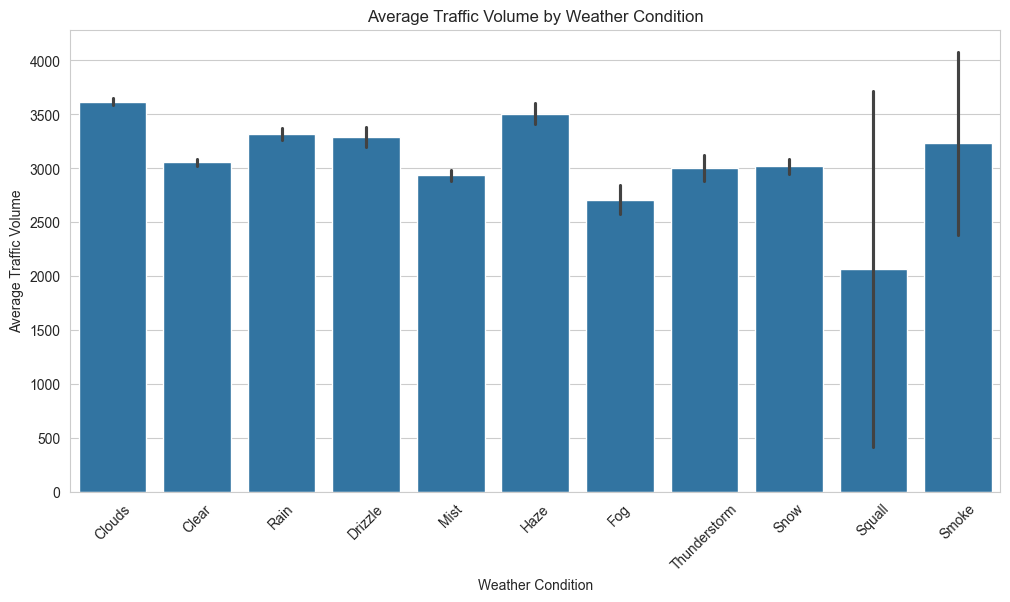

In [12]:
# 3. Impact of Weather Condition on Traffic Volume
# Using a Bar Plot to show the average traffic volume for each weather category
plt.figure()
sns.barplot(data=traffic_data, x='weather_main', y='traffic_volume')
plt.title('Average Traffic Volume by Weather Condition')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.xlabel('Weather Condition')
plt.ylabel('Average Traffic Volume')
plt.show()